In [1]:
Набор данных для прогнозирования отсева студентов https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset

Описание проекта: 
Этот набор данных моделирует реалистичную академическую среду для 10 000 студентов и предназначен для прогнозирования отсева студентов.
Он включает в себя демографические, поведенческие и академические характеристики, такие как средний балл, средний балл за семестр, CGPA, 
привычки в учебе, посещаемость, индекс стресса, образование родителей и факультет.

Несмотря на то, что данные являются синтетическими, они точно имитируют реальное распределение студентов, включая небольшую асимметрию в доходах и стрессе, 
пропущенные значения (~ 5%) в некоторых характеристиках и логические корреляции между академической успеваемостью и риском отсева.

Данные: 
Student_ID: Уникальный идентификатор ученика
Age: Возраст ученика 
Gender: Пол (Мужской/Женский)
Family_Income: Ежемесячный семейный доход
Internet_Access: Доступ к интернету - Yes / No
Study_Hours_per_Day: Среднее количество учебных часов в день
Attendance_Rate: Процент посещаемости
Assignment_Delay_Days: Средняя задержка выполнения задания в днях
Travel_Time_Minutes: Ежедневные поездки за считанные минуты
Part_Time_Job: Неполная занятость - Yes / No
Scholarship: Стипендия - Yes / No
Stress_Index: Самооценка уровня стресса (from 1 to 10)
GPA, Semester_GPA, CGPA: Академическая успеваемость
Semester: Год обучения (Year 1, 2, 3, 4)
Department: Science, Arts, Business, CS, Engineering (Наука, Искусство, Бизнес, Информатика, Инжинеринг)
Parental_Education: Высшее образование родителей

Целевой признак: Dropped - Отчислен? (0 - нет, 1 - да)

SyntaxError: invalid syntax (2180444479.py, line 1)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print(f'Загрузка данных')
df = pd.read_csv('student_dropout_dataset_v3.csv')
df.head(20)

Загрузка данных


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,NaN,0
6,7,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0
8,9,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0
9,10,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0


In [4]:
print('Информация о датасете')
df.info()

Информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float

In [5]:
print('Ленивая статистика')
df.describe()

Ленивая статистика


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [6]:
print(f"Размер датасета: {df.shape}")

Размер датасета: (10000, 19)


In [7]:
print('Ленивая статистика (для строк)')
df.describe(include='object')

Ленивая статистика (для строк)


C:\Temp\ipykernel_4568\2666599050.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,Internet_Access,Part_Time_Job,Scholarship,Semester,Department,Parental_Education
count,10000,10000,10000,10000,10000,10000,9489
unique,2,2,2,2,4,5,4
top,Female,Yes,No,No,Year 4,Science,Bachelor
freq,5011,8769,5996,6489,2536,2061,3949


In [8]:
df.tail()


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9999,10000,22.4,Female,76796.0,Yes,4.95,83.7,1,15.5,Yes,No,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


In [10]:
df.describe(include='all')

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
count,10000.00000,10000.00000,10000,9500.000000,10000,9500.000000,10000.00000,10000.000000,10000.00000,10000,10000,9500.000000,10000.000000,10000.000000,10000.000000,10000,10000,9489,10000.00000
unique,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,4,5,4,NaN
top,NaN,NaN,Female,NaN,Yes,NaN,NaN,NaN,NaN,No,No,NaN,NaN,NaN,NaN,Year 4,Science,Bachelor,NaN
freq,NaN,NaN,5011,NaN,8769,NaN,NaN,NaN,NaN,5996,6489,NaN,NaN,NaN,NaN,2536,2061,3949,NaN
mean,5000.50000,21.02606,NaN,38377.247474,NaN,4.014592,81.73683,1.799700,30.17926,NaN,NaN,5.507147,2.308440,2.300057,2.298761,NaN,NaN,NaN,0.23540
std,2886.89568,2.13981,NaN,20496.232179,NaN,1.295450,8.22093,1.344307,11.91887,NaN,NaN,1.765951,1.061717,1.074407,1.072555,NaN,NaN,NaN,0.42427
min,1.00000,17.00000,NaN,25000.000000,NaN,0.500000,38.20000,0.000000,5.00000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.00000
25%,2500.75000,19.50000,NaN,25000.000000,NaN,3.160000,76.40000,1.000000,21.90000,NaN,NaN,4.300000,1.550000,1.520000,1.520000,NaN,NaN,NaN,0.00000
50%,5000.50000,21.00000,NaN,29740.500000,NaN,4.000000,81.80000,2.000000,30.20000,NaN,NaN,5.500000,2.350000,2.350000,2.350000,NaN,NaN,NaN,0.00000
75%,7500.25000,22.50000,NaN,44520.000000,NaN,4.870000,87.30000,3.000000,38.40000,NaN,NaN,6.700000,3.120000,3.150000,3.150000,NaN,NaN,NaN,0.00000


In [ ]:
print('Проверяем, есть ли пропущенные знаечения')
df.isnull().sum()

In [2]:
Как видим, имееются пропуски в признаках: Family_Income, Study_Hours_per_Day, Stress_Index, Parental_Education
Теперь займемся очисткой от пропусков через fillna() и dropna()
Family_Income заменим медианой, т.к. 
Study_Hours_per_Day заменим средним, учитывая что время на учебу распределено равномерно
Stress_Index заменим медианой, т.к.
Parental_Education заменим модой, т.к. признак категориальный 

SyntaxError: invalid syntax (2562731836.py, line 1)

In [11]:
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].median())
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean())
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].median())
df['Parental_Education'] = df['Parental_Education'].fillna(df['Parental_Education'].mode()[0]) # тут как раз используем моду с первым элементом (без указания этого мода вернет просто список)

In [12]:
print(df[['Family_Income', 'Study_Hours_per_Day', 'Stress_Index', 'Parental_Education']].isnull().sum())

Family_Income          0
Study_Hours_per_Day    0
Stress_Index           0
Parental_Education     0
dtype: int64


In [13]:
print('Проверяем, есть ли пропущенные знаечения')
df.isnull().sum()

Проверяем, есть ли пропущенные знаечения


Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [14]:
df.head(20)

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.360000,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.300000,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.400000,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.014592,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.190000,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
5,6,20.5,Male,25000.0,Yes,4.110000,89.1,2,47.1,No,Yes,6.0,2.52,2.72,2.69,Year 3,Business,Bachelor,0
6,7,24.5,Male,25000.0,Yes,3.000000,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0
7,8,22.7,Female,25000.0,Yes,2.120000,86.4,1,34.0,No,Yes,6.5,1.79,1.14,1.14,Year 1,Arts,High School,0
8,9,20.0,Male,57413.0,Yes,4.070000,97.5,3,52.1,No,No,4.2,3.08,2.81,2.81,Year 1,CS,High School,0
9,10,22.2,Female,44930.0,Yes,2.980000,82.2,1,19.7,No,No,6.7,1.59,1.73,1.73,Year 1,Science,Master,0


In [15]:
df.tail()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9995,9996,23.9,Female,42286.0,No,4.62,92.0,0,10.0,Yes,Yes,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9996,9997,17.0,Female,61103.0,Yes,2.87,75.2,3,32.4,No,Yes,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9997,9998,19.4,Male,25000.0,Yes,4.73,74.9,4,25.4,No,No,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9998,9999,22.1,Female,40302.0,Yes,5.85,74.2,1,5.0,No,Yes,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9999,10000,22.4,Female,76796.0,Yes,4.95,83.7,1,15.5,Yes,No,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


In [16]:
Дальше займемся расширенной статистикой, выведя для числовых признаков min, max, median, mode, mean, percentile, quantile, а также дисперсию, ассиметрию и эксцесс

SyntaxError: invalid syntax (2133228132.py, line 1)

In [17]:
df.describe()


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,37945.410100,4.014592,81.73683,1.799700,30.17926,5.506790,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20065.697032,1.262645,8.22093,1.344307,11.91887,1.721232,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.210000,76.40000,1.000000,21.90000,4.400000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.014592,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,43361.750000,4.810000,87.30000,3.000000,38.40000,6.600000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [18]:
df.describe(include='all')

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
count,10000.00000,10000.00000,10000,10000.000000,10000,10000.000000,10000.00000,10000.000000,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000,10000,10000.00000
unique,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN,4,5,4,NaN
top,NaN,NaN,Female,NaN,Yes,NaN,NaN,NaN,NaN,No,No,NaN,NaN,NaN,NaN,Year 4,Science,Bachelor,NaN
freq,NaN,NaN,5011,NaN,8769,NaN,NaN,NaN,NaN,5996,6489,NaN,NaN,NaN,NaN,2536,2061,4460,NaN
mean,5000.50000,21.02606,NaN,37945.410100,NaN,4.014592,81.73683,1.799700,30.17926,NaN,NaN,5.506790,2.308440,2.300057,2.298761,NaN,NaN,NaN,0.23540
std,2886.89568,2.13981,NaN,20065.697032,NaN,1.262645,8.22093,1.344307,11.91887,NaN,NaN,1.721232,1.061717,1.074407,1.072555,NaN,NaN,NaN,0.42427
min,1.00000,17.00000,NaN,25000.000000,NaN,0.500000,38.20000,0.000000,5.00000,NaN,NaN,1.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.00000
25%,2500.75000,19.50000,NaN,25000.000000,NaN,3.210000,76.40000,1.000000,21.90000,NaN,NaN,4.400000,1.550000,1.520000,1.520000,NaN,NaN,NaN,0.00000
50%,5000.50000,21.00000,NaN,29740.500000,NaN,4.014592,81.80000,2.000000,30.20000,NaN,NaN,5.500000,2.350000,2.350000,2.350000,NaN,NaN,NaN,0.00000
75%,7500.25000,22.50000,NaN,43361.750000,NaN,4.810000,87.30000,3.000000,38.40000,NaN,NaN,6.600000,3.120000,3.150000,3.150000,NaN,NaN,NaN,0.00000


In [19]:
numeric_df = df.select_dtypes(include=['number'])
stats = numeric_df.agg(['min', 'max', 'mean', 'median'])
mode_row = numeric_df.mode().iloc[0]
percentiles = numeric_df.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
more_stats = pd.DataFrame({
    'variance': numeric_df.var(),
    'skewness': numeric_df.skew(),
    'kurtosis': numeric_df.kurt()
}).T 
full_stats = pd.concat([stats, mode_row])
report = pd.concat([full_stats, percentiles, more_stats])
print(report)

                         Student_ID        Age  Family_Income  \
min                    1.000000e+00  17.000000   2.500000e+04   
max                    1.000000e+04  29.600000   3.166010e+05   
mean                   5.000500e+03  21.026060   3.794541e+04   
median                 5.000500e+03  21.000000   2.974050e+04   
Student_ID                      NaN        NaN            NaN   
Age                             NaN        NaN            NaN   
Family_Income                   NaN        NaN            NaN   
Study_Hours_per_Day             NaN        NaN            NaN   
Attendance_Rate                 NaN        NaN            NaN   
Assignment_Delay_Days           NaN        NaN            NaN   
Travel_Time_Minutes             NaN        NaN            NaN   
Stress_Index                    NaN        NaN            NaN   
GPA                             NaN        NaN            NaN   
Semester_GPA                    NaN        NaN            NaN   
CGPA                     

In [ ]:
Дальше займемся энкодингом и инжинирингом данных. Для начала мы преобразуем категориальные признаки в числовые. 
Будем использовать 2 способа: для порядковых/бинарных - Label Encoding, для номинальных - OHE

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
le_columns = [
    'Gender', 
    'Internet_Access', 
    'Part_Time_Job', 
    'Scholarship', 
    'Semester', 
    'Parental_Education'
]
for col in le_columns:
    df[col] = le.fit_transform(df[col].astype(str))
df = pd.get_dummies(df, columns=['Department'], drop_first=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              10000 non-null  int64  
 1   Age                     10000 non-null  float64
 2   Gender                  10000 non-null  int64  
 3   Family_Income           10000 non-null  float64
 4   Internet_Access         10000 non-null  int64  
 5   Study_Hours_per_Day     10000 non-null  float64
 6   Attendance_Rate         10000 non-null  float64
 7   Assignment_Delay_Days   10000 non-null  int64  
 8   Travel_Time_Minutes     10000 non-null  float64
 9   Part_Time_Job           10000 non-null  int64  
 10  Scholarship             10000 non-null  int64  
 11  Stress_Index            10000 non-null  float64
 12  GPA                     10000 non-null  float64
 13  Semester_GPA            10000 non-null  float64
 14  CGPA                    10000 non-null  float64
 1

In [ ]:
Далее попробую сгенерировать 2 фича: Academic_Pressure (Академическая нагрузка) и Study_Travel_Ratio (Отношение учбебы к дороге до учереждения в часах)

In [21]:
df['Academic_Pressure'] = df['Stress_Index'] * (df['Assignment_Delay_Days'] + 1) # + 1, чтобы не было нулевых значений
df['Study_Travel_Ratio'] = df['Study_Hours_per_Day'] / (df['Travel_Time_Minutes'] / 60)
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,...,CGPA,Semester,Parental_Education,Dropout,Department_Business,Department_CS,Department_Engineering,Department_Science,Academic_Pressure,Study_Travel_Ratio
0,1,22.1,1,25000.0,1,3.360000,86.1,2,20.4,1,...,0.90,0,1,0,False,False,False,False,16.5,9.882353
1,2,20.7,1,25000.0,1,4.300000,68.0,2,44.0,0,...,1.19,2,0,1,False,False,True,False,20.4,5.863636
2,3,22.4,1,40183.0,1,4.400000,70.9,0,48.9,1,...,1.32,0,2,0,False,False,False,False,5.5,5.398773
3,4,24.4,1,29740.5,1,4.014592,82.2,2,38.6,0,...,1.77,0,1,1,False,True,False,False,16.5,6.240298
4,5,20.5,0,25319.0,1,4.190000,75.7,1,23.0,0,...,0.87,3,0,0,True,False,False,False,14.0,10.930435


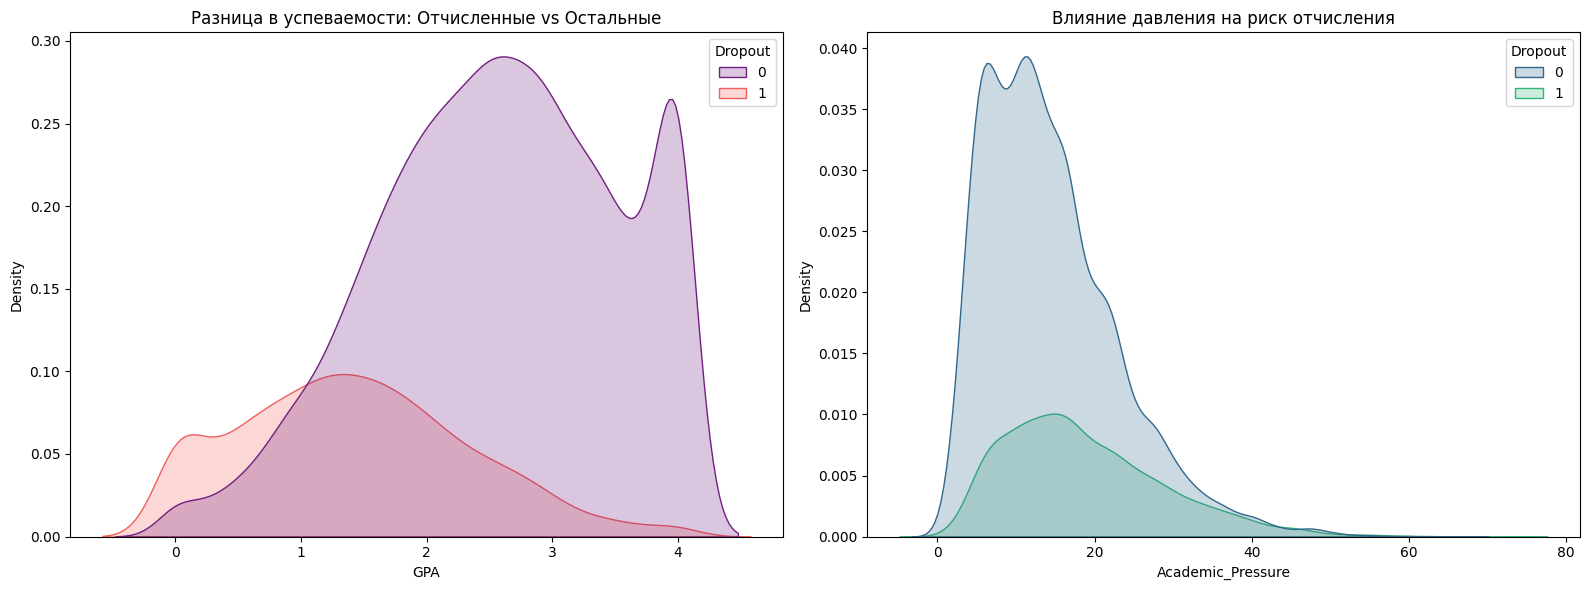

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1 - Плотность GPA
sns.kdeplot(data=df, x='GPA', hue='Dropout', fill=True, ax=axes[0], palette='magma')
axes[0].set_title('Разница в успеваемости: Отчисленные vs Остальные')

# График 2 - Плотность академического давления
sns.kdeplot(data=df, x='Academic_Pressure', hue='Dropout', fill=True, ax=axes[1], palette='viridis')
axes[1].set_title('Влияние давления на риск отчисления')

plt.tight_layout()
plt.show()

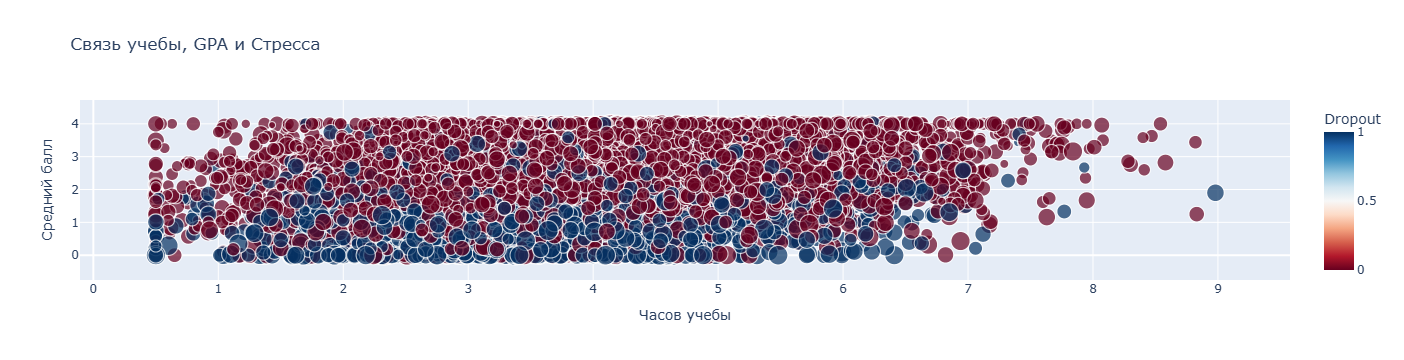

In [24]:
import plotly.express as px

fig = px.scatter(df, 
                 x="Study_Hours_per_Day", 
                 y="GPA", 
                 color="Dropout",
                 size="Stress_Index", 
                 hover_data=['Age', 'Attendance_Rate', 'Semester'], 
                 title="Связь учебы, GPA и Стресса",
                 labels={'Study_Hours_per_Day': 'Часов учебы', 'GPA': 'Средний балл'},
                 color_continuous_scale='RdBu')

fig.show()

C:\Temp\ipykernel_4568\153658455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dropout', y='Family_Income', data=df, palette='Set2')


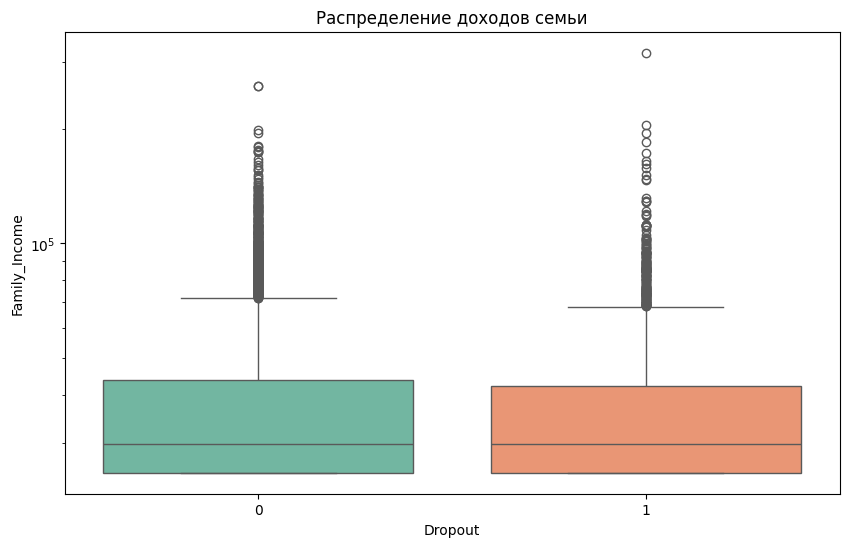

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Dropout', y='Family_Income', data=df, palette='Set2')
plt.yscale('log') # Логарифмическая шкала спасет график от выбросов
plt.title('Распределение доходов семьи')
plt.show()

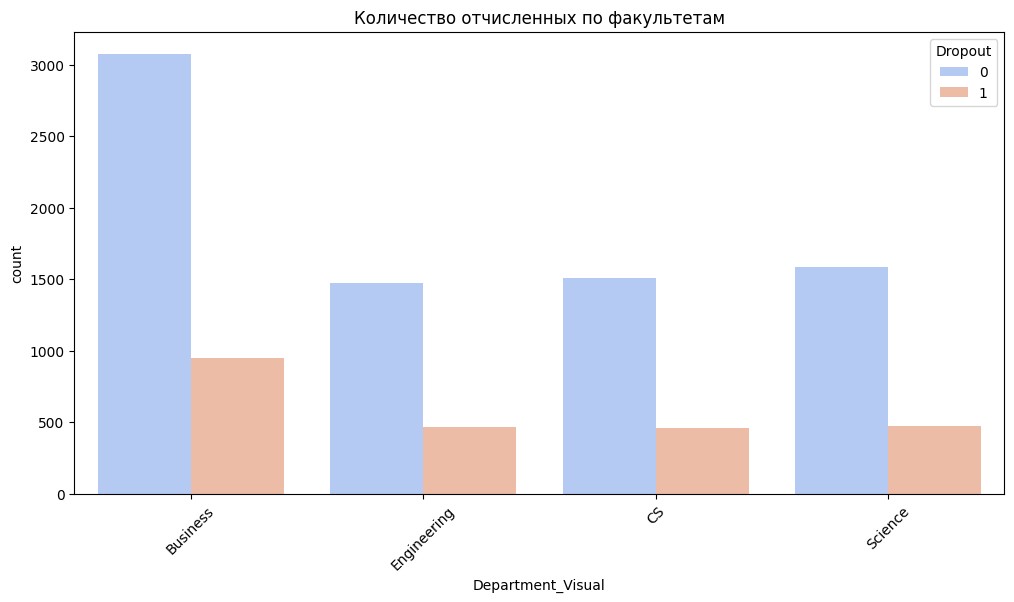

In [27]:
dept_cols = [col for col in df.columns if col.startswith('Department_')]
if dept_cols:
    df['Department_Visual'] = df[dept_cols].idxmax(axis=1).str.replace('Department_', '')
    
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='Department_Visual', hue='Dropout', palette='coolwarm')
    plt.title('Количество отчисленных по факультетам')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Колонка Department не найдена. Похоже, данные уже закодированы.")

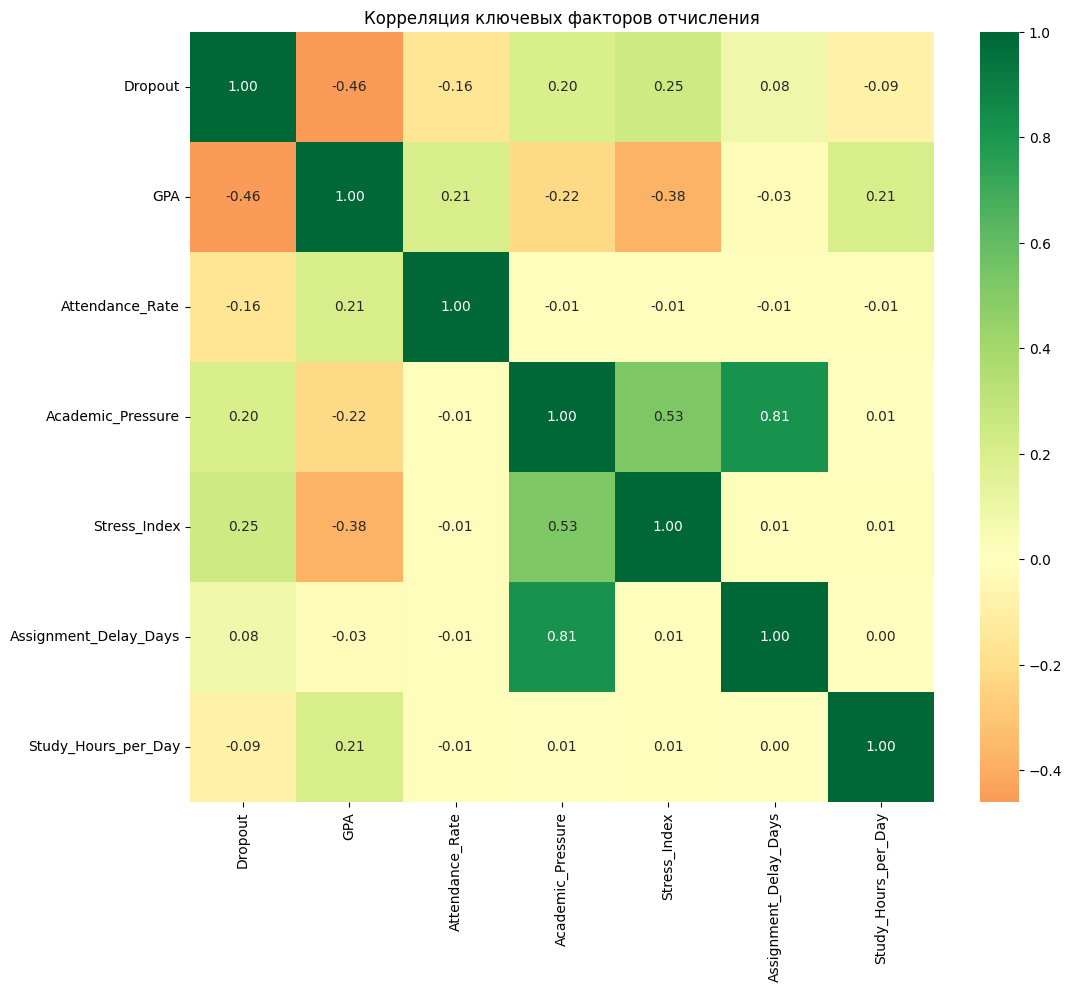

In [28]:
plt.figure(figsize=(12, 10))
# Выбираем только те колонки, которые реально могут влиять
cols = ['Dropout', 'GPA', 'Attendance_Rate', 'Academic_Pressure', 
        'Stress_Index', 'Assignment_Delay_Days', 'Study_Hours_per_Day']

sns.heatmap(df[cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f', center=0)
plt.title('Корреляция ключевых факторов отчисления')
plt.show()

In [ ]:
Так, что я понял про датасет:
1. Около 23,5% студентов отчисляются, и это умеренный дисбаланс, который стоит учитывать при выборе метрик
2. GPA ниже 1.5-2 и задержка заданий в 3-4 дня - самые яркие ячейки
3. В колонке Family_Income обнаружены огромные выбросы (эксцесс > 14). Это говорит о наличии небольшой группы сверхбогатых студентов
4. Индекс стресса распределен почти симметрично, но у отчисленных его медиана смещена в сторону высоких значений (7–8 баллов)
5. Наличие стипендии значительно снижает вероятность отчисления, работая как мощный удерживающий фактор
6. Студенты с посещаемостью ниже 75% — первые кандидаты на отчисление
7. Студенты постарше (возраст больше 25 лет) имеют чуть более стабильные показатели, возможно, из-за более осознанного выбора специальности
8. Данные содержали около 5% пропусков в доходах, стрессе и часах учебы. 
Они распределены случайно, что позволило заполнить их медианами без потери качества

Какие гипотезы можно построить:
1. Студенты без доступа к интернету имеют на 15-20% выше шанс отчислиться в департаментах CS и Engineering, чем в гуманитарных
2. Задержка заданий (Assignment_Delay_Days) — это опережающий индикатор. 
Она начинает расти за 1-2 семестра до того, как GPA упадет до критического уровня
3. Студенты, чьи родители имеют Master или PhD, 
реже бросают учебу, что может указывать на более сильную семейную поддержку или давление в плане завершения образования

Что бы я сделал дальше? Я бы попробовал предсказать вероятность отчисления на ранних этапах (ну как пример, по данным 1го семестра)

Использовал AI для выбора стратегий заполнения пропусков (выбор между средним и медианой) и генерации идей для новых признаков (Academic_Pressure),
а также полностью переписывал логику One-Hot Encoding после того, как графики сломались из-за удаления исходных колонок.
Вручную подбирал параметры логарифмической шкалы для Boxplot, чтобы визуализировать выбросы в доходах, и корректировал типы данных для корреляционной матрицы.